In [1]:
import os
import csv
import librosa
import numpy as np


directory = r'C:\Users\yashu\Downloads\SAMPLE' 


def extract_features(songname):
    try:
        
        y, sr = librosa.load(songname, mono=True, duration=30)
        
        
        chroma_stft = np.mean(librosa.feature.chroma_stft(y=y, sr=sr))
        rms = np.mean(librosa.feature.rms(y=y))
        spec_cent = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
        spec_bw = np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr))
        rolloff = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))
        zcr = np.mean(librosa.feature.zero_crossing_rate(y))
        
        
        harmony, percussive = librosa.effects.hpss(y)
        

        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
        mfcc_means = [np.mean(e) for e in mfcc]
        
        return [chroma_stft, rms, spec_cent, spec_bw, rolloff, zcr, np.mean(harmony), np.mean(percussive)] + mfcc_means
    except Exception as e:
        
        print(f"   Skipping {os.path.basename(songname)}: {e}")
        return None


header = 'filename chroma_stft rmse spec_cent spec_bw rolloff zcr harmony percussive ' + ' '.join([f'mfcc{i}' for i in range(1, 21)]) + ' label'
header = header.split()

if not os.path.exists(directory):
    print(f"CRITICAL ERROR: The path '{directory}' does not exist.")
else:
    print(f"Scanning: {directory}")
    
    with open('music_data.csv', 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(header)
        
        total_processed = 0
        
        
        for root, dirs, files in os.walk(directory):
        
            label = os.path.basename(root)
            
            
            audio_files = [f for f in files if f.lower().endswith(('.wav', '.mp3', '.au', '.flac'))]
            
            if audio_files:
                print(f"Found {len(audio_files)} audio files in folder: {label}")
                
                for filename in audio_files:
                    path = os.path.join(root, filename)
                    features = extract_features(path)
                    
                    if features:
                        writer.writerow([filename] + features + [label])
                        total_processed += 1
                        if total_processed % 5 == 0:
                            print(f"   Successfully processed {total_processed} files...")

    print(f"\n--- DONE! Processed {total_processed} total songs. ---")
    if total_processed > 0:
        print("You can now run Cell 2.")

Scanning: C:\Users\yashu\Downloads\SAMPLE
Found 8 audio files in folder: classical
   Successfully processed 5 files...
Found 8 audio files in folder: hiphop
   Successfully processed 10 files...
   Successfully processed 15 files...
Found 10 audio files in folder: jazz
   Successfully processed 20 files...
   Successfully processed 25 files...

--- DONE! Processed 26 total songs. ---
You can now run Cell 2.


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

try:
    
    data = pd.read_csv('music_data.csv')
    X = data.drop(['label', 'filename'], axis=1)
    y = data['label']

    
    encoder = LabelEncoder()
    y_encoded = encoder.fit_transform(y)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

  
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y_encoded, test_size=0.2, random_state=1
    )
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    
    y_pred = model.predict(X_test)
    
  
    present_classes = encoder.inverse_transform(np.unique(np.concatenate((y_test, y_pred))))

    print("="*30)
    print(f"ACCURACY: {accuracy_score(y_test, y_pred) * 100:.2f}%")
    print("="*30)
    print("\nDetailed Report for visible classes:")
    print(classification_report(y_test, y_pred, target_names=present_classes, zero_division=0))

    test_idx = 0 
    single_pred = model.predict(X_scaled[test_idx].reshape(1, -1))
    print(f"\n--- Prediction Test ---")
    print(f"File: {data['filename'].iloc[test_idx]}")
    print(f"AI Thinks this is: {encoder.inverse_transform(single_pred)[0]}")

except Exception as e:
    print(f"Error: {e}")

ACCURACY: 100.00%

Detailed Report for visible classes:
              precision    recall  f1-score   support

   classical       1.00      1.00      1.00         1
      hiphop       1.00      1.00      1.00         2
        jazz       1.00      1.00      1.00         3

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6


--- Prediction Test ---
File: classical.mp3
AI Thinks this is: classical


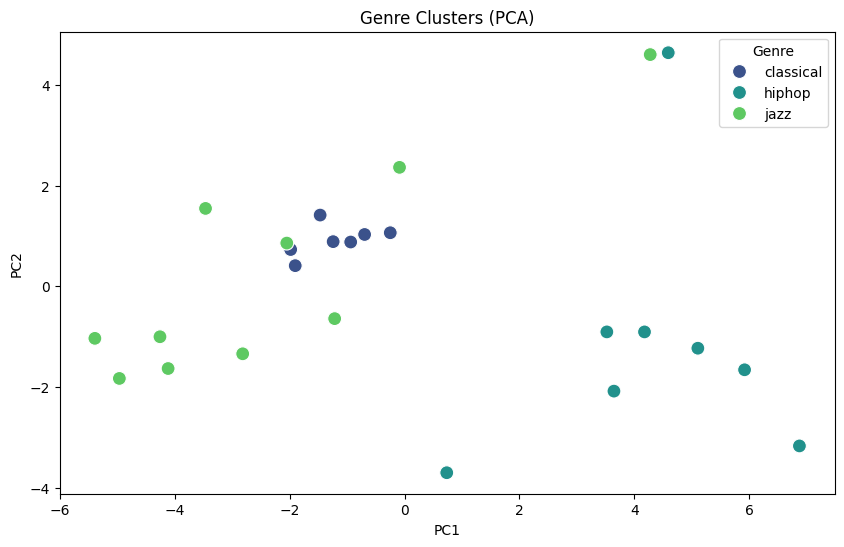

In [3]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import seaborn as sns


pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


df_pca = pd.DataFrame(data = X_pca, columns = ['PC1', 'PC2'])
df_pca['Genre'] = y


plt.figure(figsize=(10, 6))
sns.scatterplot(x='PC1', y='PC2', hue='Genre', data=df_pca, s=100, palette='viridis')
plt.title('Genre Clusters (PCA)')
plt.show()

In [9]:
import librosa
import numpy as np
import os
import joblib
import pandas as pd
import warnings


warnings.filterwarnings("ignore", category=UserWarning)


joblib.dump(model, 'music_genre_model.pkl')
joblib.dump(scaler, 'music_scaler.pkl')
joblib.dump(encoder, 'music_encoder.pkl')
print("✅ AI Brains Saved Successfully!")

def predict_single_song(song_path):
    try:
        y, sr = librosa.load(song_path, mono=True, duration=30)
        
        
        chroma_stft = np.mean(librosa.feature.chroma_stft(y=y, sr=sr))
        rms = np.mean(librosa.feature.rms(y=y))
        spec_cent = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
        spec_bw = np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr))
        rolloff = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))
        zcr = np.mean(librosa.feature.zero_crossing_rate(y))
        harmony, percussive = librosa.effects.hpss(y)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
        mfcc_means = [np.mean(e) for e in mfcc]
        
        feature_vector = [chroma_stft, rms, spec_cent, spec_bw, rolloff, zcr, 
                         np.mean(harmony), np.mean(percussive)] + mfcc_means
        
      
        column_names = ['chroma_stft', 'rmse', 'spec_cent', 'spec_bw', 
                        'rolloff', 'zcr', 'harmony', 'percussive'] + [f'mfcc{i+1}' for i in range(20)]
        
        feature_df = pd.DataFrame([feature_vector], columns=column_names)
        
      
        scaled_feature = scaler.transform(feature_df)
        prediction = model.predict(scaled_feature)
        genre = encoder.inverse_transform(prediction)[0]
        
        probs = model.predict_proba(scaled_feature)[0]
        conf = max(probs) * 100
        
        print("\n" + "="*40)
        print(f"SONG: {os.path.basename(song_path)}")
        print(f"PREDICTED GENRE: {genre.upper()}")
        print(f"CONFIDENCE: {conf:.2f}%")
        print("="*40)

    except Exception as e:
        print(f"Error processing song: {e}")


test_path = r"C:\Users\yashu\Downloads\memphis-trap-memphis-trap-wav-349366 (1).mp3"
predict_single_song(test_path)

✅ AI Brains Saved Successfully!

SONG: memphis-trap-memphis-trap-wav-349366 (1).mp3
PREDICTED GENRE: JAZZ
CONFIDENCE: 81.00%


In [5]:
import joblib


joblib.dump(model, 'music_genre_model.pkl')
joblib.dump(scaler, 'music_scaler.pkl')
joblib.dump(encoder, 'music_encoder.pkl')

print("--- MODEL SAVED SUCCESSFULLY ---")
print("Files created: music_genre_model.pkl, music_scaler.pkl, music_encoder.pkl")

--- MODEL SAVED SUCCESSFULLY ---
Files created: music_genre_model.pkl, music_scaler.pkl, music_encoder.pkl
